In [1]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

In [2]:
seed = 2724

### Import data

In [15]:
DF_PATH = "mod04_data/sample.csv"
df = pd.read_csv(DF_PATH)

### Separate data by independent (X) and dependent (y) variables

In [4]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [6]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=2724)

### Use SHAP to explain the model on test data

In [7]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

 99%|===================| 1485/1500 [01:10<00:00]        

This will allow us to see which variables are most important to predicting the outcome.

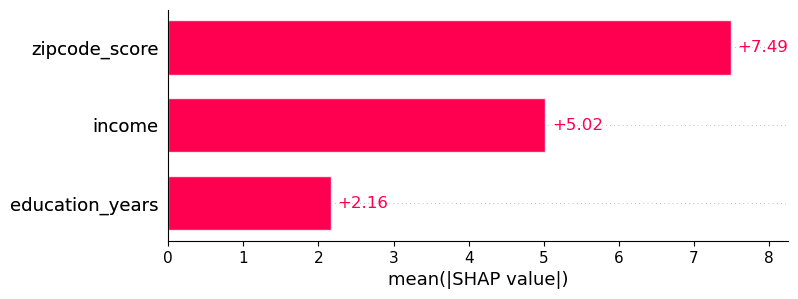

In [8]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [9]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [10]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.086254,-0.170779,5.866534
1,1.020094,-0.192841,-6.859435


### Let's put `group` and `zipcode_score` in the same plot

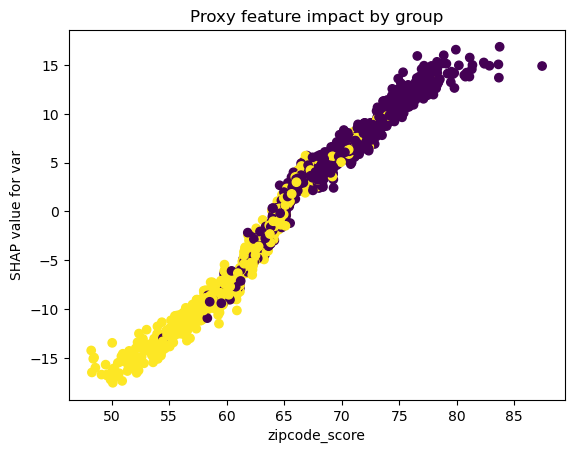

In [ ]:
def plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value? 

A SHAP value represents how much its corresponding feature or input contributed to the model's prediction. If we add the shap values to a baseline, then we recieve the model's predicted output; thus a greater (absolute) value represents more importance in the model, and the sign of the SHAP value represents whether the impact on the target is positive or negative.

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

The group variable was not used in training the model. Income, years of education, and zipcode score were the only features used in our model.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

The outcome of our model appears to still be correlated with group due to the correlation between group and zipcode score. As shown by the "proxy feature impact by group" plot for zipcode score, group 0 is correlated with greater zipcode scores and greater (and positive) SHAP values. So, while group does not appear in the model, it is correlated with zipcode score, and therefore correlated with the final result of our model.

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

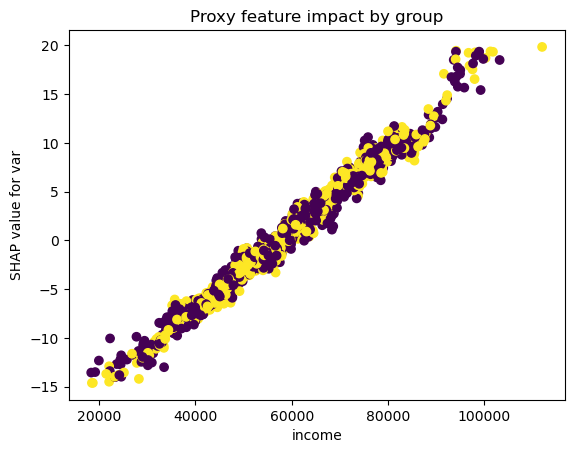

In [13]:
plot_shap("income")

In the plot for zipcode score, there was an obvious separation between the two groups, but this separation is not seen for income; the income of the two groups seems to be evenly distributed, as opposed to the zipcode scores being clearly higher for group 0 in the zipcode score plot. Essentially, income does not seem to have a strong correlation with groups.

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

-Why was the group variable not used in the final model?
-What does zipcode score actually represent?
-Why is there a strong correlation between zipcode score and group? Does it have to do with geographical location?
-What about the evaluation metrics of the model (MSE, R Squared,etc.)?